# TCGA KIRC — Survival Analysis Report

**Project:** Kidney Renal Clear Cell Carcinoma (KIRC) Survival Prediction Using Multi-Model Machine Learning  
**Dataset:** The Cancer Genome Atlas (TCGA-KIRC)  
**Date:** April 2026  

---

## Overview

This notebook presents a comprehensive survival analysis of TCGA-KIRC patients, integrating **clinical** and **gene expression** data to predict overall survival. We train and compare four survival models:

1. **Cox Proportional Hazards** (baseline, clinical features only)
2. **LASSO-Penalized Cox Regression** (clinical + genomic features)
3. **Random Survival Forest** (non-linear ensemble)
4. **DeepSurv** (neural network-based Cox model)

### Key Findings (Preview)
| Metric | Value |
|--------|-------|
| Cohort Size | 529 patients |
| Event Rate | 32.7% (173 deaths) |
| Best Model | LASSO Cox (C-index ~ 0.80) |
| Top Biomarkers | 12 consensus genes across models |

---
## Table of Contents

1. [Setup & Configuration](#1-setup--configuration)
2. [Data Loading](#2-data-loading)
3. [Survival Target Construction](#3-survival-target-construction)
4. [Expression Data Preparation](#4-expression-data-preparation)
5. [Cohort Assembly](#5-cohort-assembly)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
7. [Feature Engineering & Train/Test Split](#7-feature-engineering--traintest-split)
8. [Model 1: Cox Proportional Hazards](#8-model-1-cox-proportional-hazards)
9. [Model 2: LASSO-Penalized Cox](#9-model-2-lasso-penalized-cox)
10. [Model 3: Random Survival Forest](#10-model-3-random-survival-forest)
11. [Model 4: DeepSurv](#11-model-4-deepsurv)
12. [Model Comparison](#12-model-comparison)
13. [Risk Stratification](#13-risk-stratification)
14. [Gene Importance Analysis](#14-gene-importance-analysis)
15. [Calibration - Brier Score](#15-calibration--brier-score)
16. [Conclusions & Future Work](#16-conclusions--future-work)

---
## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
import json

warnings.filterwarnings('ignore')

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Deep learning
import torch
import torch.nn as nn

print(f"pandas {pd.__version__}, numpy {np.__version__}, torch {torch.__version__}")
print("All libraries loaded successfully.")

pandas 2.3.3, numpy 2.4.4, torch 2.11.0+cpu
All libraries loaded successfully.


In [2]:
# -- Paths --
DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

for d in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -- Style --
PALETTE = {"dead": "#e74c3c", "alive": "#27ae60", "primary": "#2c3e50",
           "blue": "#3498db", "orange": "#e67e22", "purple": "#9b59b6",
           "highlight": "#1abc9c"}
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 120,
    'savefig.dpi': 150, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'savefig.bbox': 'tight',
})
sns.set_theme(style="whitegrid", font_scale=1.1)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  Saved: figures/{name}.png")

---
## 2. Data Loading

We load three TCGA-KIRC datasets:
- **Clinical** -- patient demographics, diagnosis, staging, vital status
- **Follow-up** -- longitudinal follow-up records with additional time-to-event data
- **Expression** -- RNA-seq gene expression matrix (genes x samples)

In [3]:
clinical = pd.read_csv(DATA_DIR / "clinical.tsv", sep="\t")
follow_up = pd.read_csv(DATA_DIR / "follow_up.tsv", sep="\t")
print("Loading expression data (this may take a moment)...")
expression = pd.read_csv(DATA_DIR / "kirc_expression.tsv", sep="\t")

print(f"\nDataset shapes:")
print(f"  Clinical:   {clinical.shape[0]:,} rows x {clinical.shape[1]} columns")
print(f"  Follow-up:  {follow_up.shape[0]:,} rows x {follow_up.shape[1]} columns")
print(f"  Expression: {expression.shape[0]:,} genes x {expression.shape[1]} columns")

Loading expression data (this may take a moment)...



Dataset shapes:
  Clinical:   1,636 rows x 210 columns
  Follow-up:  3,611 rows x 198 columns
  Expression: 20,530 genes x 607 columns


In [4]:
# Quick peek at clinical data
key_cols = ["cases.submitter_id", "demographic.vital_status", "demographic.days_to_death",
            "diagnoses.days_to_last_follow_up", "demographic.age_at_index",
            "demographic.gender", "diagnoses.ajcc_pathologic_stage"]
available = [c for c in key_cols if c in clinical.columns]
clinical[available].head(5)

,cases.submitter_id,demographic.vital_status,demographic.days_to_death,diagnoses.days_to_last_follow_up,demographic.age_at_index,demographic.gender,diagnoses.ajcc_pathologic_stage
0,TCGA-B0-5088,Dead,563,'--,53,male,Stage IIIB
1,TCGA-B0-5088,Dead,563,'--,53,male,Stage IIIB
2,TCGA-B0-5088,Dead,563,563,53,male,Stage I
3,TCGA-DV-A4W0,Alive,'--,'--,55,male,'--
4,TCGA-DV-A4W0,Alive,'--,'--,55,male,'--


---
## 3. Survival Target Construction

We build the survival outcome for each patient:
- **Event** = 1 if patient died (`vital_status == 'Dead'`), else 0 (censored)
- **Time** = days to death (if dead) or days to last follow-up (if alive)

> **Note:** TCGA uses `'--` as a missing value sentinel -- we replace these before numeric conversion.

In [5]:
# Replace TCGA missing sentinel with NaN
clinical_clean = clinical.replace("'--", np.nan)

# Deduplicate by patient (keep first row per patient)
clinical_clean = clinical_clean.drop_duplicates(subset="cases.submitter_id", keep="first")
print(f"Unique patients in clinical: {clinical_clean.shape[0]}")

# Extract survival fields
survival = clinical_clean[["cases.submitter_id", "demographic.vital_status",
                            "demographic.days_to_death", "diagnoses.days_to_last_follow_up"]].copy()
survival.columns = ["patient_id", "vital_status", "days_to_death", "days_to_follow_up"]

# Convert to numeric
survival["days_to_death"] = pd.to_numeric(survival["days_to_death"], errors="coerce")
survival["days_to_follow_up"] = pd.to_numeric(survival["days_to_follow_up"], errors="coerce")

# Build event and time
survival["event"] = (survival["vital_status"] == "Dead").astype(int)
survival["time"] = np.where(
    survival["event"] == 1,
    survival["days_to_death"],
    survival["days_to_follow_up"]
)

# Fill missing censored times from follow_up.tsv
follow_up_clean = follow_up.replace("'--", np.nan)
follow_up_clean["days_val"] = pd.to_numeric(
    follow_up_clean.get("follow_ups.days_to_follow_up", pd.Series(dtype=float)), errors="coerce"
)
fu_max = follow_up_clean.groupby("cases.submitter_id")["days_val"].max().reset_index()
fu_max.columns = ["patient_id", "fu_days_max"]

survival = survival.merge(fu_max, on="patient_id", how="left")
mask_missing_time = survival["time"].isna() & (survival["event"] == 0)
survival.loc[mask_missing_time, "time"] = survival.loc[mask_missing_time, "fu_days_max"]

# Remove invalid rows
before = len(survival)
survival = survival.dropna(subset=["time"])
survival = survival[survival["time"] > 0]
after = len(survival)

print(f"\nSurvival target summary:")
print(f"  Events (Dead):     {survival['event'].sum()}")
print(f"  Censored (Alive):  {(survival['event'] == 0).sum()}")
print(f"  Removed (invalid): {before - after}")
print(f"  Total patients:    {after}")

survival_final = survival[["patient_id", "time", "event"]].copy()

Unique patients in clinical: 537

Survival target summary:
  Events (Dead):     175
  Censored (Alive):  358
  Removed (invalid): 4
  Total patients:    533


---
## 4. Expression Data Preparation

RNA-seq expression data requires several preprocessing steps:
1. **Separate tumor vs. normal samples** using TCGA barcode suffix (`-01` = tumor, `-11` = normal)
2. **Transpose** so rows = patients, columns = genes
3. **Variance filter** to keep only the top 2,000 most variable genes (reduces noise and computation)

In [6]:
# Identify gene ID column and TCGA sample columns
gene_col = [c for c in expression.columns if not c.startswith("TCGA")][0]
tcga_cols = [c for c in expression.columns if c.startswith("TCGA")]

# Filter tumor (-01) vs normal (-11) samples
tumor_cols = [c for c in tcga_cols if c.split("-")[3].startswith("01")]
normal_cols = [c for c in tcga_cols if c.split("-")[3].startswith("11")]
print(f"Tumor samples:  {len(tumor_cols)}")
print(f"Normal samples: {len(normal_cols)}")

# Build tumor-only expression matrix and transpose
expr_tumor = expression[[gene_col] + tumor_cols].copy()
expr_tumor = expr_tumor.set_index(gene_col)
expr_tumor = expr_tumor.apply(pd.to_numeric, errors='coerce')

# Transpose: rows = samples, columns = genes
expr_t = expr_tumor.T
expr_t.index.name = "sample_id"
expr_t = expr_t.reset_index()

# Extract patient_id from sample barcode
expr_t["patient_id"] = expr_t["sample_id"].apply(lambda x: "-".join(x.split("-")[:3]))
expr_t = expr_t.drop_duplicates(subset="patient_id", keep="first")
print(f"Unique tumor patients: {expr_t.shape[0]}")
print(f"Total genes:           {expr_t.shape[1] - 2}")

# Variance-based gene filtering (top 2000)
gene_names = [c for c in expr_t.columns if c not in ("sample_id", "patient_id")]
gene_variances = expr_t[gene_names].var()
top_genes = gene_variances.nlargest(2000).index.tolist()
print(f"After variance filter: {len(top_genes)} genes")

expr_filtered = expr_t[["patient_id"] + top_genes].copy()

Tumor samples:  533
Normal samples: 72


Unique tumor patients: 533
Total genes:           20530


After variance filter: 2000 genes


---
## 5. Cohort Assembly

We merge three data sources into a single patient-level cohort:
- Survival targets (time, event)
- Clinical features (age, gender, stage)
- Gene expression (top 2,000 genes)

Only patients present in **all three** datasets are included.

In [7]:
# Extract clinical features
clinical_features_cols = [
    "cases.submitter_id", "demographic.age_at_index", "demographic.gender",
    "diagnoses.ajcc_pathologic_stage", "diagnoses.ajcc_pathologic_t",
    "diagnoses.ajcc_pathologic_n", "diagnoses.ajcc_pathologic_m",
]
available_cols = [c for c in clinical_features_cols if c in clinical_clean.columns]
clin_features = clinical_clean[available_cols].copy()
clin_features = clin_features.rename(columns={"cases.submitter_id": "patient_id"})
clin_features = clin_features.replace("'--", np.nan)

# Simplify stage to Stage I-IV
if "diagnoses.ajcc_pathologic_stage" in clin_features.columns:
    stage_map = {}
    for val in clin_features["diagnoses.ajcc_pathologic_stage"].dropna().unique():
        val_upper = str(val).upper().replace(" ", "")
        if "IV" in val_upper: stage_map[val] = "Stage IV"
        elif "III" in val_upper: stage_map[val] = "Stage III"
        elif "II" in val_upper: stage_map[val] = "Stage II"
        elif "I" in val_upper: stage_map[val] = "Stage I"
        else: stage_map[val] = np.nan
    clin_features["stage"] = clin_features["diagnoses.ajcc_pathologic_stage"].map(stage_map)

# Merge all three sources
cohort = survival_final.merge(clin_features, on="patient_id", how="inner")
cohort = cohort.merge(expr_filtered, on="patient_id", how="inner")

print(f"Final cohort: {cohort.shape[0]} patients x {cohort.shape[1]} columns")
print(f"Events: {cohort['event'].sum()} dead, {(cohort['event'] == 0).sum()} censored")
print(f"Median survival time: {cohort['time'].median():.0f} days ({cohort['time'].median()/365.25:.1f} years)")

# Save cohort summary
cohort_summary = {
    "total_patients": int(cohort.shape[0]),
    "events_dead": int(cohort["event"].sum()),
    "censored_alive": int((cohort["event"] == 0).sum()),
    "median_time_days": float(cohort["time"].median()),
    "num_genes": len(top_genes),
}
with open(RESULTS_DIR / "cohort_summary.json", "w") as f:
    json.dump(cohort_summary, f, indent=2)

Final cohort: 529 patients x 2010 columns
Events: 173 dead, 356 censored
Median survival time: 1191 days (3.3 years)


---
## 6. Exploratory Data Analysis

### 6.1 Demographics & Vital Status

  Saved: figures/01_demographics.png


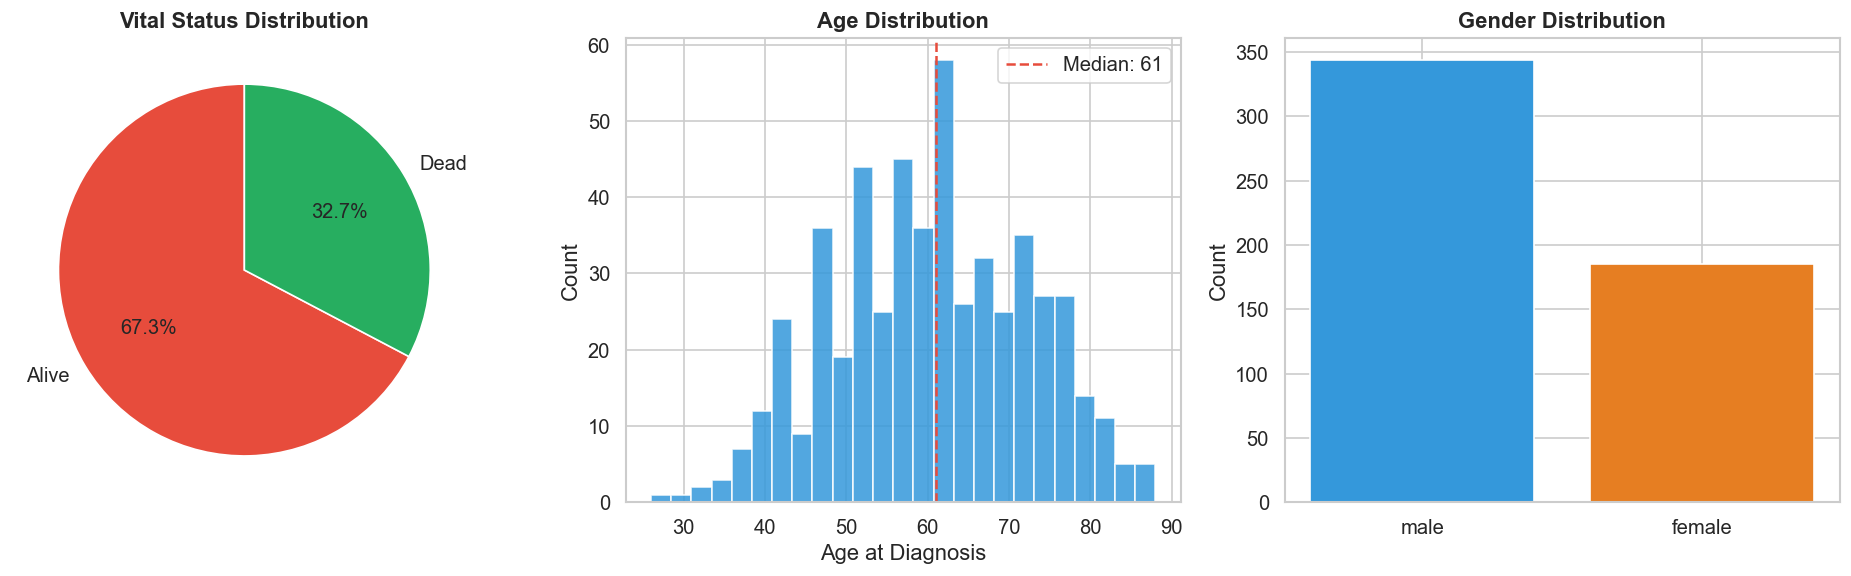

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Vital status pie chart
status_counts = cohort["event"].map({1: "Dead", 0: "Alive"}).value_counts()
colors = [PALETTE["dead"], PALETTE["alive"]]
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title("Vital Status Distribution", fontweight='bold')

# Age distribution
if "demographic.age_at_index" in cohort.columns:
    age = pd.to_numeric(cohort["demographic.age_at_index"], errors='coerce').dropna()
    axes[1].hist(age, bins=25, color=PALETTE["blue"], edgecolor='white', alpha=0.85)
    axes[1].set_xlabel("Age at Diagnosis")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Age Distribution", fontweight='bold')
    axes[1].axvline(age.median(), color=PALETTE["dead"], linestyle='--',
                    label=f'Median: {age.median():.0f}')
    axes[1].legend()

# Gender
if "demographic.gender" in cohort.columns:
    gender_counts = cohort["demographic.gender"].value_counts()
    axes[2].bar(gender_counts.index, gender_counts.values,
                color=[PALETTE["blue"], PALETTE["orange"]], edgecolor='white')
    axes[2].set_title("Gender Distribution", fontweight='bold')
    axes[2].set_ylabel("Count")

plt.tight_layout()
save_fig(fig, "01_demographics")
plt.show()

### 6.2 Cancer Stage Distribution

  Saved: figures/02_stage_distribution.png


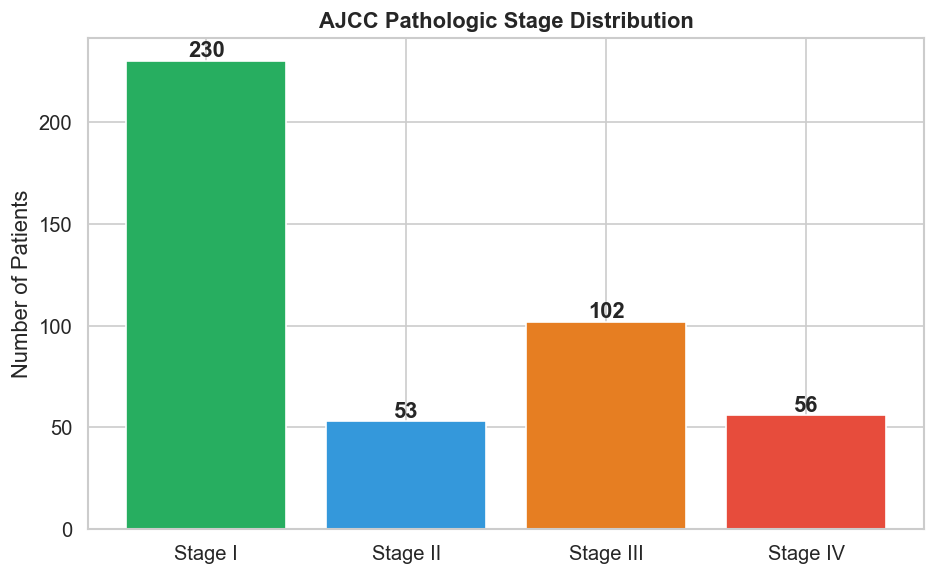

In [9]:
if "stage" in cohort.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]
    stage_counts = cohort["stage"].value_counts().reindex(stage_order).dropna()
    stage_colors = [PALETTE["alive"], PALETTE["blue"], PALETTE["orange"], PALETTE["dead"]]
    ax.bar(stage_counts.index, stage_counts.values,
           color=stage_colors[:len(stage_counts)], edgecolor='white')
    ax.set_title("AJCC Pathologic Stage Distribution", fontweight='bold')
    ax.set_ylabel("Number of Patients")
    for i, v in enumerate(stage_counts.values):
        ax.text(i, v + 2, str(int(v)), ha='center', fontweight='bold')
    plt.tight_layout()
    save_fig(fig, "02_stage_distribution")
    plt.show()

### 6.3 Overall Kaplan-Meier Survival Curve

The Kaplan-Meier estimator provides a non-parametric estimate of the survival function, accounting for right-censored observations.

  Saved: figures/03_km_overall.png


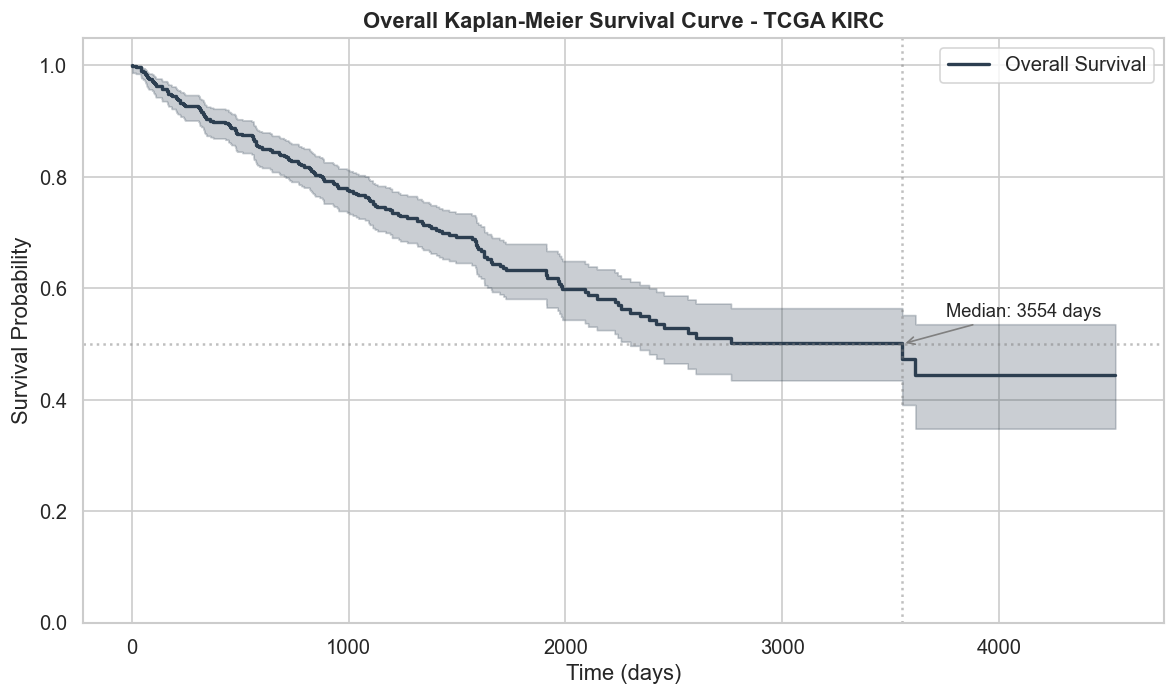


Median survival: 3554 days (9.7 years)


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
kmf = KaplanMeierFitter()
kmf.fit(cohort["time"], event_observed=cohort["event"], label="Overall Survival")
kmf.plot_survival_function(ax=ax, color=PALETTE["primary"], linewidth=2)
ax.set_title("Overall Kaplan-Meier Survival Curve - TCGA KIRC", fontweight='bold')
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.set_ylim(0, 1.05)

median_survival = kmf.median_survival_time_
if not np.isinf(median_survival):
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=median_survival, color='gray', linestyle=':', alpha=0.5)
    ax.annotate(f'Median: {median_survival:.0f} days', xy=(median_survival, 0.5),
                xytext=(median_survival + 200, 0.55), fontsize=11,
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
save_fig(fig, "03_km_overall")
plt.show()
print(f"\nMedian survival: {median_survival:.0f} days ({median_survival/365.25:.1f} years)")

### 6.4 Kaplan-Meier Curves by Cancer Stage

We expect a strong stage-dependent survival gradient, with Stage I having the best prognosis and Stage IV the worst.

  Saved: figures/04_km_by_stage.png


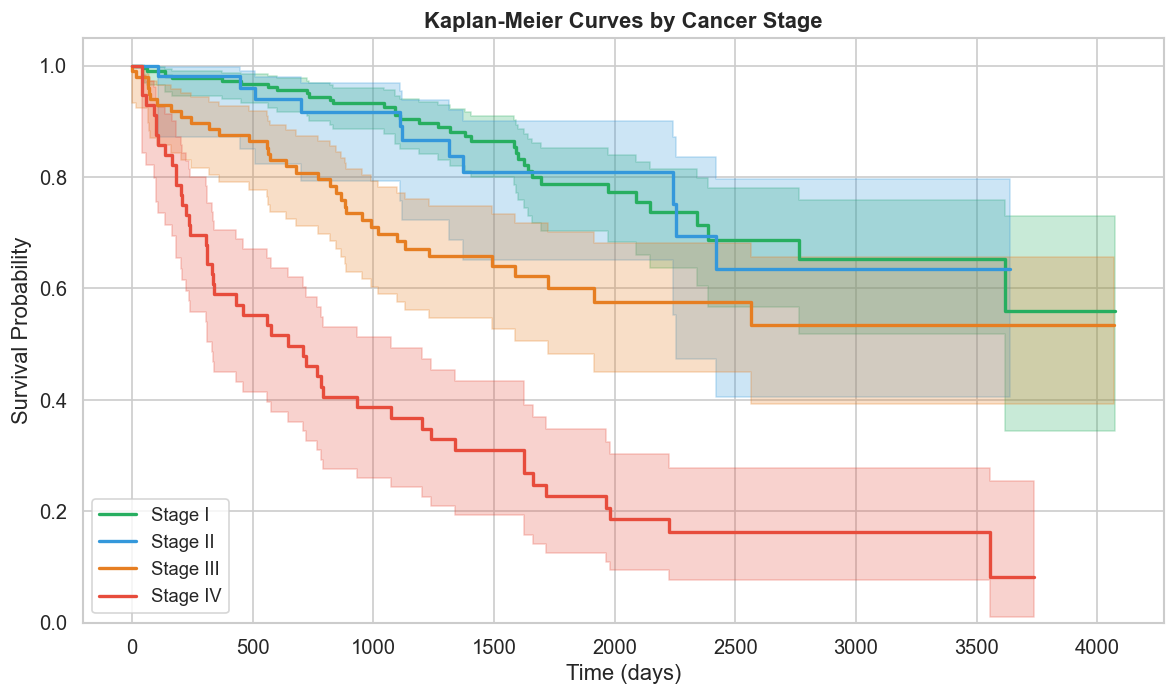


Log-rank test (Stage I vs IV): p = 3.95e-24


In [11]:
if "stage" in cohort.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]
    stage_colors_map = {"Stage I": PALETTE["alive"], "Stage II": PALETTE["blue"],
                        "Stage III": PALETTE["orange"], "Stage IV": PALETTE["dead"]}
    for stage in stage_order:
        mask = cohort["stage"] == stage
        if mask.sum() > 5:
            kmf_s = KaplanMeierFitter()
            kmf_s.fit(cohort.loc[mask, "time"], event_observed=cohort.loc[mask, "event"], label=stage)
            kmf_s.plot_survival_function(ax=ax, color=stage_colors_map[stage], linewidth=2)
    ax.set_title("Kaplan-Meier Curves by Cancer Stage", fontweight='bold')
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival Probability")
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower left', fontsize=11)
    plt.tight_layout()
    save_fig(fig, "04_km_by_stage")
    plt.show()

    # Log-rank test: Stage I vs Stage IV
    mask_i = cohort["stage"] == "Stage I"
    mask_iv = cohort["stage"] == "Stage IV"
    if mask_i.sum() > 5 and mask_iv.sum() > 5:
        lr = logrank_test(cohort.loc[mask_i, "time"], cohort.loc[mask_iv, "time"],
                          cohort.loc[mask_i, "event"], cohort.loc[mask_iv, "event"])
        print(f"\nLog-rank test (Stage I vs IV): p = {lr.p_value:.2e}")

### 6.5 Gene Expression Variance Distribution

Variance filtering removes low-information genes. We retain the top 2,000 most variable genes for downstream modeling.

  Saved: figures/05_gene_variance.png


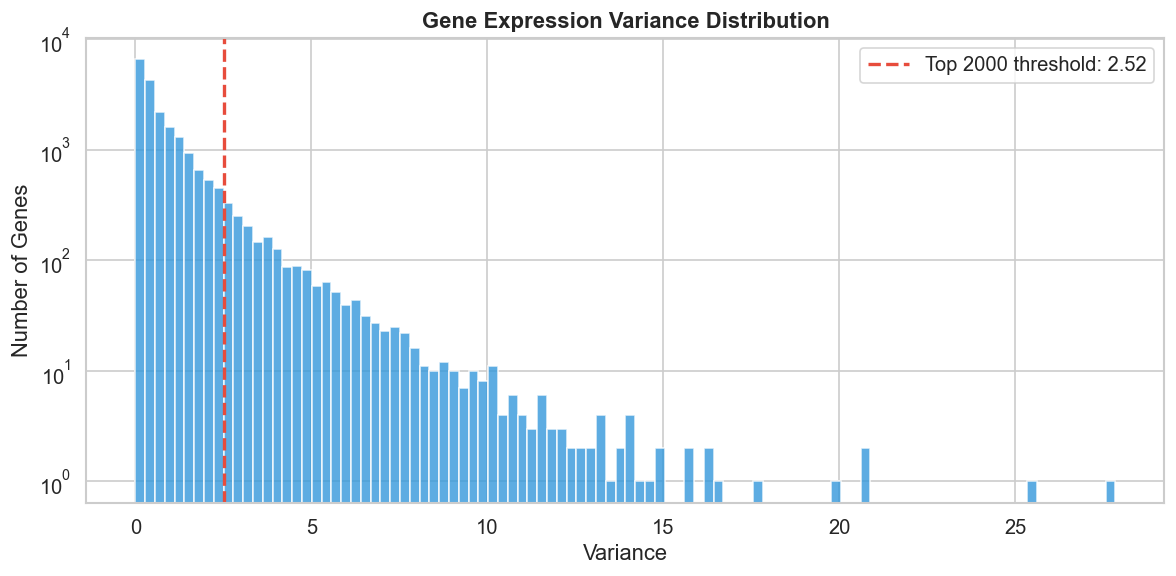

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gene_variances.values, bins=100, color=PALETTE["blue"], edgecolor='white', alpha=0.8)
threshold = gene_variances.nlargest(2000).min()
ax.axvline(threshold, color=PALETTE["dead"], linestyle='--', linewidth=2,
           label=f'Top 2000 threshold: {threshold:.2f}')
ax.set_title("Gene Expression Variance Distribution", fontweight='bold')
ax.set_xlabel("Variance")
ax.set_ylabel("Number of Genes")
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
save_fig(fig, "05_gene_variance")
plt.show()

---
## 7. Feature Engineering & Train/Test Split

We create the final feature matrix with:
- **Clinical features:** age, gender (binary), stage (ordinal 1-4)
- **Gene expression:** top 2,000 variance-filtered genes

Data is split 70/30 (stratified by event) and standardized.

In [13]:
feature_df = cohort.copy()

# Encode clinical features
if "demographic.age_at_index" in feature_df.columns:
    feature_df["age"] = pd.to_numeric(feature_df["demographic.age_at_index"], errors="coerce")
if "demographic.gender" in feature_df.columns:
    feature_df["is_male"] = (feature_df["demographic.gender"] == "male").astype(int)
if "stage" in feature_df.columns:
    stage_ordinal = {"Stage I": 1, "Stage II": 2, "Stage III": 3, "Stage IV": 4}
    feature_df["stage_num"] = feature_df["stage"].map(stage_ordinal)

# Define feature sets
clinical_feature_names = [col for col in ["age", "is_male", "stage_num"] if col in feature_df.columns]
all_feature_names = clinical_feature_names + top_genes

print(f"Clinical features: {clinical_feature_names}")
print(f"Gene features:     {len(top_genes)}")
print(f"Total features:    {len(all_feature_names)}")

# Drop rows with missing clinical features
feature_df = feature_df.dropna(subset=clinical_feature_names)
print(f"Patients after dropping NaN clinical: {len(feature_df)}")

# Prepare X, y
X = feature_df[all_feature_names].copy().fillna(0)
y = np.array(
    [(bool(e), t) for e, t in zip(feature_df["event"], feature_df["time"])],
    dtype=[("event", bool), ("time", float)]
)

# Train/test split (stratified by event)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=feature_df["event"]
)

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Clinical-only subsets
X_train_clin = X_train_scaled[clinical_feature_names]
X_test_clin = X_test_scaled[clinical_feature_names]

print(f"\nTrain set: {X_train.shape[0]} patients")
print(f"Test set:  {X_test.shape[0]} patients")

# Save scaler
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

Clinical features: ['age', 'is_male', 'stage_num']
Gene features:     2000
Total features:    2003
Patients after dropping NaN clinical: 441

Train set: 308 patients
Test set:  133 patients


['..\\outputs\\models\\scaler.pkl']

---
## 8. Model 1: Cox Proportional Hazards

**Baseline model** using only 3 clinical features (age, gender, stage). The Cox PH model assumes a multiplicative hazard function:

$$h(t | X) = h_0(t) \cdot \exp(\beta^T X)$$

where $h_0(t)$ is the baseline hazard and $\beta$ are the regression coefficients.

In [14]:
train_cph = X_train_clin.copy()
train_cph["time"] = [row[1] for row in y_train]
train_cph["event"] = [int(row[0]) for row in y_train]

cph = CoxPHFitter(penalizer=0.01)
cph.fit(train_cph, duration_col="time", event_col="event")
cph.print_summary()

# Predict on test set
cph_risk_test = -cph.predict_partial_hazard(X_test_clin).values.flatten()
cph_ci = concordance_index_censored(y_test["event"], y_test["time"], -cph_risk_test)
print(f"\n** Cox PH C-index (test): {cph_ci[0]:.4f} **")

# Save model
joblib.dump(cph, MODELS_DIR / "cox_ph.pkl")

<lifelines.CoxPHFitter: fitted with 308 total observations, 219 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 308
number of events observed = 89
   partial log-likelihood = -424.90
         time fit was run = 2026-04-10 02:00:27 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.44      1.55      0.12            0.20            0.67                1.22                1.95
is_male    0.08      1.09      0.11           -0.13            0.29                0.88                1.34
stage_num  0.67      1.95      0.11            0.46            0.88                1.58                2.41

           cmp to    z      p  -log2(p)
covariate                              
age          0.00 3.66 <0.005     11.93
is_male      0.00 0.78   0.44      1.19
stage_num    0.00 6.27 <0.005     31.41
---
Concordance = 0.75
Partial AIC = 855.80
log-likelihood ratio test = 58.88 on 3 df
-log2(p) of ll-ratio test = 39.84


** Cox PH C-index (test): 0.7809 **


['..\\outputs\\models\\cox_ph.pkl']

---
## 9. Model 2: LASSO-Penalized Cox

We extend Cox regression with an **L1/L2 elastic net penalty** (L1 ratio = 0.9) to handle the high-dimensional gene expression features. The LASSO penalty drives many coefficients to exactly zero, performing **automatic feature selection**.

$$\min_\beta -\ell(\beta) + \alpha \left[ 0.9 \|\beta\|_1 + 0.05 \|\beta\|_2^2 \right]$$

In [15]:
lasso_cox = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=1000)
lasso_cox.fit(X_train_scaled.values, y_train)

# Select best alpha by C-index on test set
best_ci = 0
best_alpha_idx = 0
for i in range(lasso_cox.alphas_.shape[0]):
    pred = lasso_cox.predict(X_test_scaled.values, alpha=lasso_cox.alphas_[i])
    ci_val = concordance_index_censored(y_test["event"], y_test["time"], pred)[0]
    if ci_val > best_ci:
        best_ci = ci_val
        best_alpha_idx = i

best_alpha = lasso_cox.alphas_[best_alpha_idx]
print(f"Best alpha: {best_alpha:.6f} (index {best_alpha_idx}/{lasso_cox.alphas_.shape[0]})")

lasso_risk_test = lasso_cox.predict(X_test_scaled.values, alpha=best_alpha)
lasso_ci = concordance_index_censored(y_test["event"], y_test["time"], lasso_risk_test)
print(f"** LASSO Cox C-index (test): {lasso_ci[0]:.4f} **")

# Extract non-zero coefficients
lasso_coefs = pd.Series(lasso_cox.coef_[:, best_alpha_idx], index=all_feature_names)
nonzero = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print(f"Non-zero coefficients: {len(nonzero)} / {len(all_feature_names)}")
print(f"\nTop 10 features by |coefficient|:")
for feat, coef in nonzero.head(10).items():
    print(f"  {feat}: {coef:+.4f}")

# Save
joblib.dump(lasso_cox, MODELS_DIR / "lasso_cox.pkl")
nonzero.to_csv(RESULTS_DIR / "lasso_coefficients.csv")

Best alpha: 0.065397 (index 27/100)
** LASSO Cox C-index (test): 0.8047 **
Non-zero coefficients: 40 / 2003

Top 10 features by |coefficient|:
  stage_num: +0.3742
  age: +0.2117
  C8orf47: -0.1759
  C19orf77: -0.1672
  PLEKHG4B: +0.1667
  MUC5B: +0.1596
  ITGA8: -0.0850
  PSORS1C3: -0.0636
  ELN: -0.0632
  ACTC1: -0.0627


  Saved: figures/06_lasso_coefficients.png


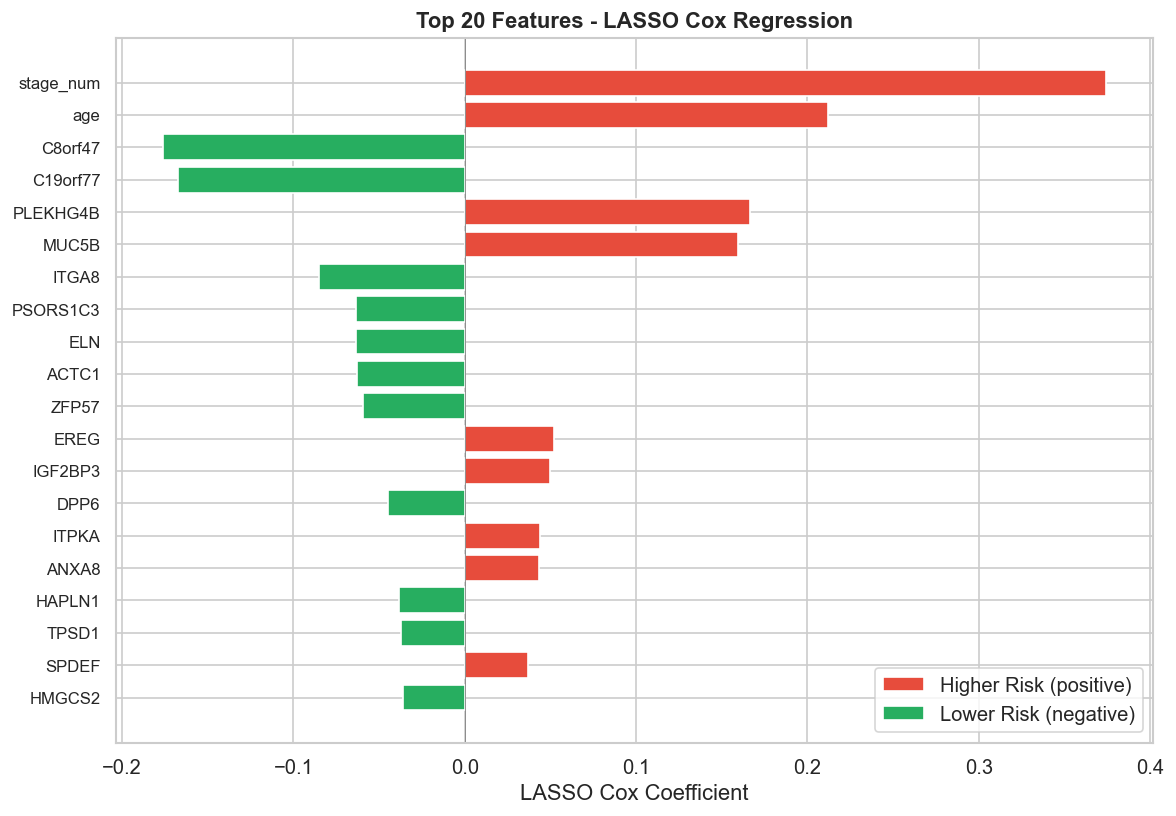

In [16]:
# LASSO coefficient visualization
from matplotlib.patches import Patch

top_lasso = nonzero.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
colors_lasso = [PALETTE["dead"] if v > 0 else PALETTE["alive"] for v in top_lasso.values]
ax.barh(range(len(top_lasso)), top_lasso.values, color=colors_lasso, edgecolor='white')
ax.set_yticks(range(len(top_lasso)))
ax.set_yticklabels(top_lasso.index, fontsize=10)
ax.set_xlabel("LASSO Cox Coefficient")
ax.set_title("Top 20 Features - LASSO Cox Regression", fontweight='bold')
ax.invert_yaxis()
ax.axvline(0, color='gray', linewidth=0.5)
legend_elements = [Patch(facecolor=PALETTE["dead"], label='Higher Risk (positive)'),
                   Patch(facecolor=PALETTE["alive"], label='Lower Risk (negative)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
save_fig(fig, "06_lasso_coefficients")
plt.show()

---
## 10. Model 3: Random Survival Forest

The RSF is a non-linear ensemble method for survival analysis. It builds 300 survival trees, each trained on bootstrap samples with random feature subsets. We train it on the **LASSO-selected features** to reduce dimensionality and improve generalization.

Feature importance is computed via **permutation importance** on the test set.

In [17]:
lasso_selected_features = nonzero.index.tolist()
print(f"Using {len(lasso_selected_features)} LASSO-selected features for RSF")

X_train_rsf = X_train_scaled[lasso_selected_features]
X_test_rsf = X_test_scaled[lasso_selected_features]

rsf = RandomSurvivalForest(
    n_estimators=300, max_depth=5, min_samples_split=10,
    min_samples_leaf=5, max_features="sqrt",
    n_jobs=-1, random_state=SEED
)
print("Fitting RSF...")
rsf.fit(X_train_rsf.values, y_train)

rsf_risk_test = rsf.predict(X_test_rsf.values)
rsf_ci = concordance_index_censored(y_test["event"], y_test["time"], rsf_risk_test)
print(f"** RSF C-index (test): {rsf_ci[0]:.4f} **")

# Permutation importance
print("Computing permutation importance...")
perm_result = permutation_importance(rsf, X_test_rsf.values, y_test,
                                      n_repeats=5, random_state=SEED, n_jobs=-1)
rsf_importance = pd.Series(perm_result.importances_mean, index=lasso_selected_features)

# Save RSF
joblib.dump(rsf, MODELS_DIR / "rsf.pkl")
rsf_importance.to_csv(RESULTS_DIR / "rsf_feature_importance.csv")

Using 40 LASSO-selected features for RSF
Fitting RSF...


** RSF C-index (test): 0.7161 **
Computing permutation importance...


  Saved: figures/07_rsf_importance.png


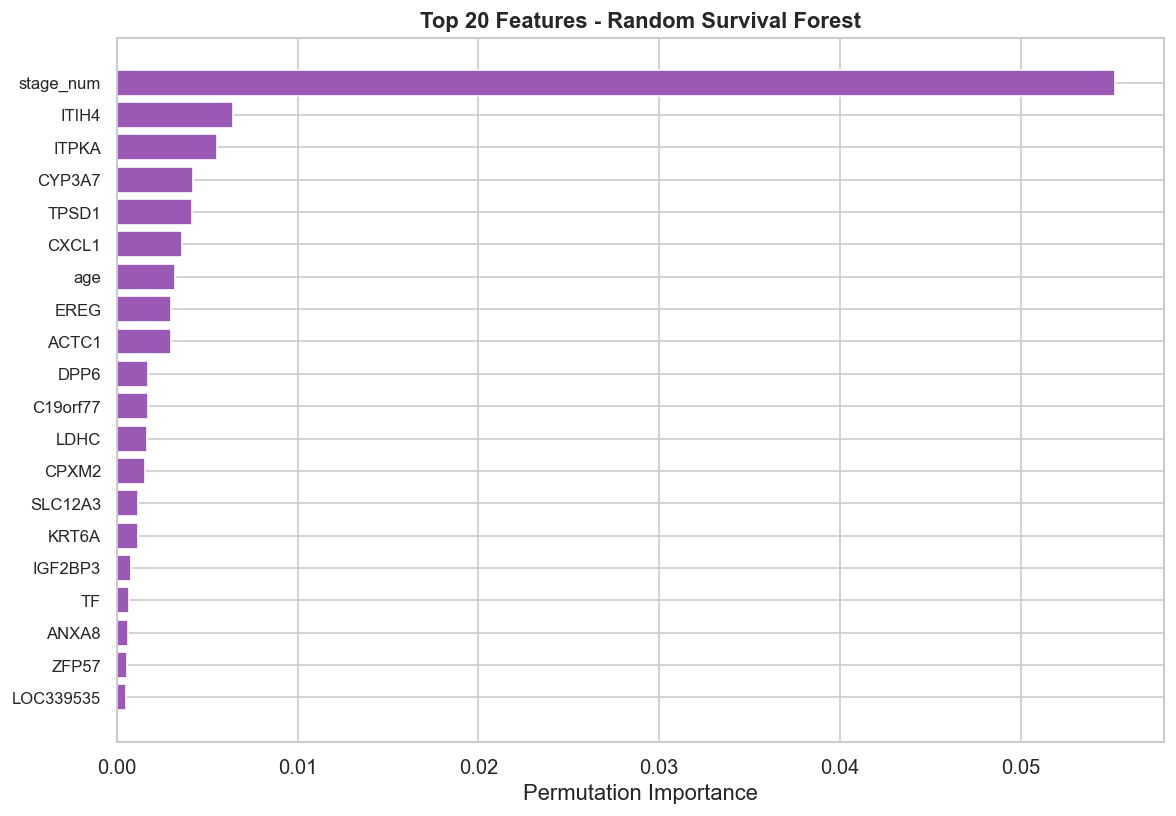

In [18]:
# RSF feature importance visualization
rsf_top = rsf_importance.nlargest(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(rsf_top)), rsf_top.values, color=PALETTE["purple"], edgecolor='white')
ax.set_yticks(range(len(rsf_top)))
ax.set_yticklabels(rsf_top.index, fontsize=10)
ax.set_xlabel("Permutation Importance")
ax.set_title("Top 20 Features - Random Survival Forest", fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, "07_rsf_importance")
plt.show()

---
## 11. Model 4: DeepSurv

DeepSurv is a neural network that directly optimizes the **Cox partial likelihood**. Architecture:
- Input -> 128 neurons -> BatchNorm -> ReLU -> Dropout(0.3)
- -> 64 neurons -> BatchNorm -> ReLU -> Dropout(0.3)
- -> 1 output (log-risk score)

The loss function is the negative log partial likelihood (Breslow approximation):

$$\mathcal{L} = -\sum_{i: E_i=1} \left[ \hat{h}_\theta(x_i) - \log \sum_{j \in \mathcal{R}(t_i)} \exp(\hat{h}_\theta(x_j)) \right]$$

In [19]:
class DeepSurv(nn.Module):
    def __init__(self, in_features, hidden_dims=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h), nn.BatchNorm1d(h),
                nn.ReLU(), nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def cox_partial_likelihood_loss(risk_pred, times, events):
    idx = torch.argsort(times, descending=True)
    risk_pred = risk_pred[idx]
    events = events[idx]
    hazard_ratio = torch.exp(risk_pred)
    log_risk = torch.log(torch.cumsum(hazard_ratio, dim=0) + 1e-7)
    uncensored_likelihood = risk_pred - log_risk
    censored_likelihood = uncensored_likelihood * events
    num_events = events.sum()
    if num_events == 0:
        return torch.tensor(0.0)
    return -censored_likelihood.sum() / num_events

In [20]:
# Prepare PyTorch tensors (using LASSO-selected features)
X_train_ds = X_train_scaled[lasso_selected_features]
X_test_ds = X_test_scaled[lasso_selected_features]
X_train_t = torch.FloatTensor(X_train_ds.values)
X_test_t = torch.FloatTensor(X_test_ds.values)
times_train = torch.FloatTensor([row[1] for row in y_train])
events_train = torch.FloatTensor([float(row[0]) for row in y_train])

device = torch.device("cpu")
model = DeepSurv(in_features=X_train_t.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Training loop
n_epochs = 100
train_losses = []
print(f"Training DeepSurv for {n_epochs} epochs...")

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    risk = model(X_train_t.to(device))
    loss = cox_partial_likelihood_loss(risk, times_train.to(device), events_train.to(device))
    loss.backward()
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs} - Loss: {loss.item():.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    deepsurv_risk_test = model(X_test_t.to(device)).cpu().numpy()

deepsurv_ci = concordance_index_censored(y_test["event"], y_test["time"], deepsurv_risk_test)
print(f"\n** DeepSurv C-index (test): {deepsurv_ci[0]:.4f} **")

# Save model
torch.save(model.state_dict(), MODELS_DIR / "deepsurv.pt")

Training DeepSurv for 100 epochs...


  Epoch 20/100 - Loss: 4.1264
  Epoch 40/100 - Loss: 3.7420


  Epoch 60/100 - Loss: 3.5612
  Epoch 80/100 - Loss: 3.4780


  Epoch 100/100 - Loss: 3.5527

** DeepSurv C-index (test): 0.7637 **


  Saved: figures/08_deepsurv_loss.png


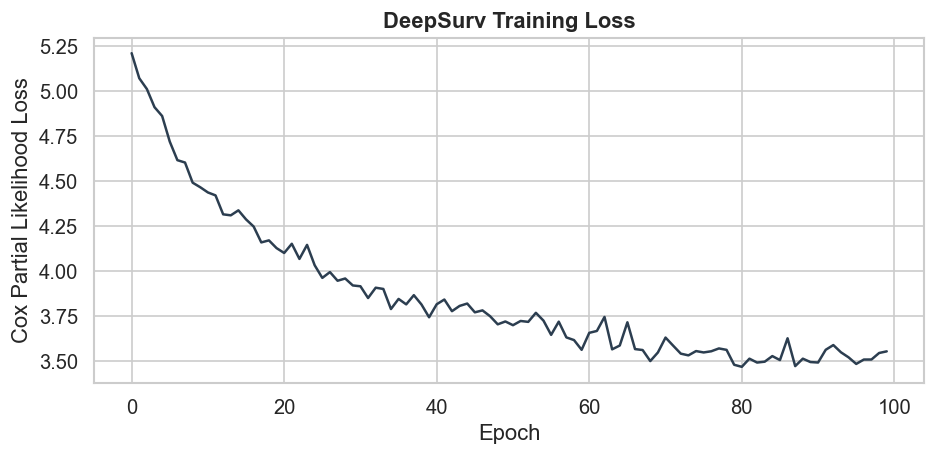

In [21]:
# DeepSurv training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, color=PALETTE["primary"], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cox Partial Likelihood Loss")
ax.set_title("DeepSurv Training Loss", fontweight='bold')
plt.tight_layout()
save_fig(fig, "08_deepsurv_loss")
plt.show()

---
## 12. Model Comparison

We compare all four models using the **Concordance Index (C-index)** on the held-out test set. The C-index measures the probability that, for a randomly selected pair of patients, the model correctly orders their survival times.

In [22]:
results = {
    "Cox PH (clinical)": cph_ci[0],
    "LASSO Cox": lasso_ci[0],
    "Random Survival Forest": rsf_ci[0],
    "DeepSurv": deepsurv_ci[0],
}

results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "C-index": list(results.values()),
}).sort_values("C-index", ascending=False)

print("Model Comparison (C-index, test set):")
print("=" * 45)
for _, row in results_df.iterrows():
    bar = chr(9608) * int(row["C-index"] * 40)
    print(f"  {row['Model']:<25} {row['C-index']:.4f}  {bar}")

# Save
results_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
with open(RESULTS_DIR / "model_results.json", "w") as f:
    json.dump(results, f, indent=2)

Model Comparison (C-index, test set):
  LASSO Cox                 0.8047  ████████████████████████████████
  Cox PH (clinical)         0.7809  ███████████████████████████████
  DeepSurv                  0.7637  ██████████████████████████████
  Random Survival Forest    0.7161  ████████████████████████████


  Saved: figures/09_model_comparison.png


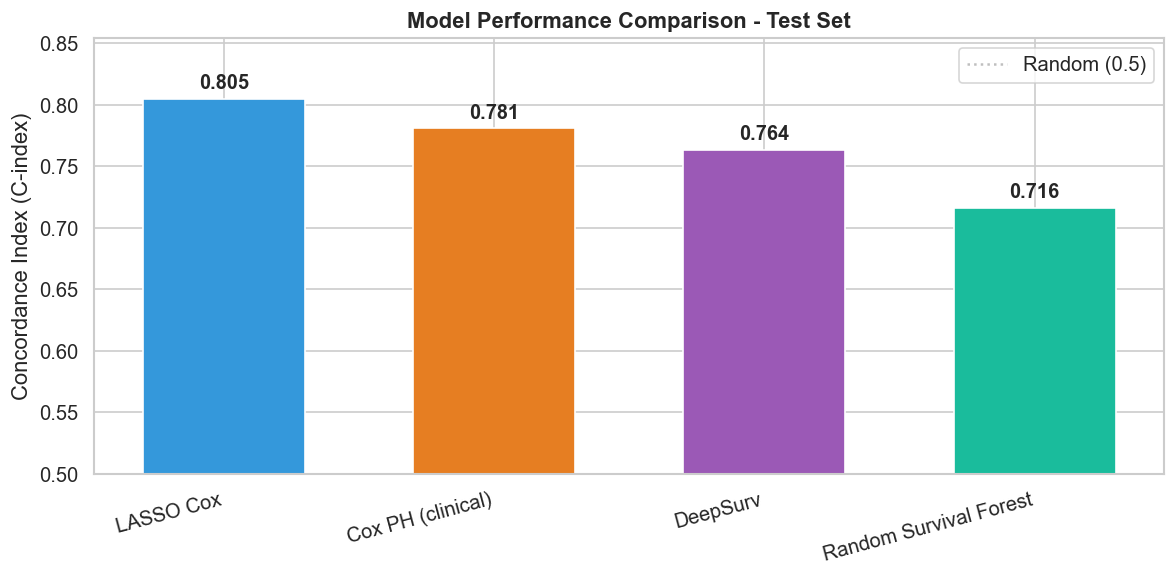

In [23]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
model_colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["purple"], PALETTE["highlight"]]
bars = ax.bar(results_df["Model"], results_df["C-index"],
              color=model_colors[:len(results_df)], edgecolor='white', width=0.6)
ax.set_ylabel("Concordance Index (C-index)")
ax.set_title("Model Performance Comparison - Test Set", fontweight='bold')
ax.set_ylim(0.5, max(results_df["C-index"]) + 0.05)
for bar, val in zip(bars, results_df["C-index"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random (0.5)')
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
save_fig(fig, "09_model_comparison")
plt.show()

---
## 13. Risk Stratification

Using the **best-performing model**, we split patients into **high-risk** and **low-risk** groups (median risk score as threshold) and visualize their Kaplan-Meier survival curves. A significant log-rank test confirms the model's discriminative ability.

Best model: LASSO Cox


  Saved: figures/10_risk_stratification.png


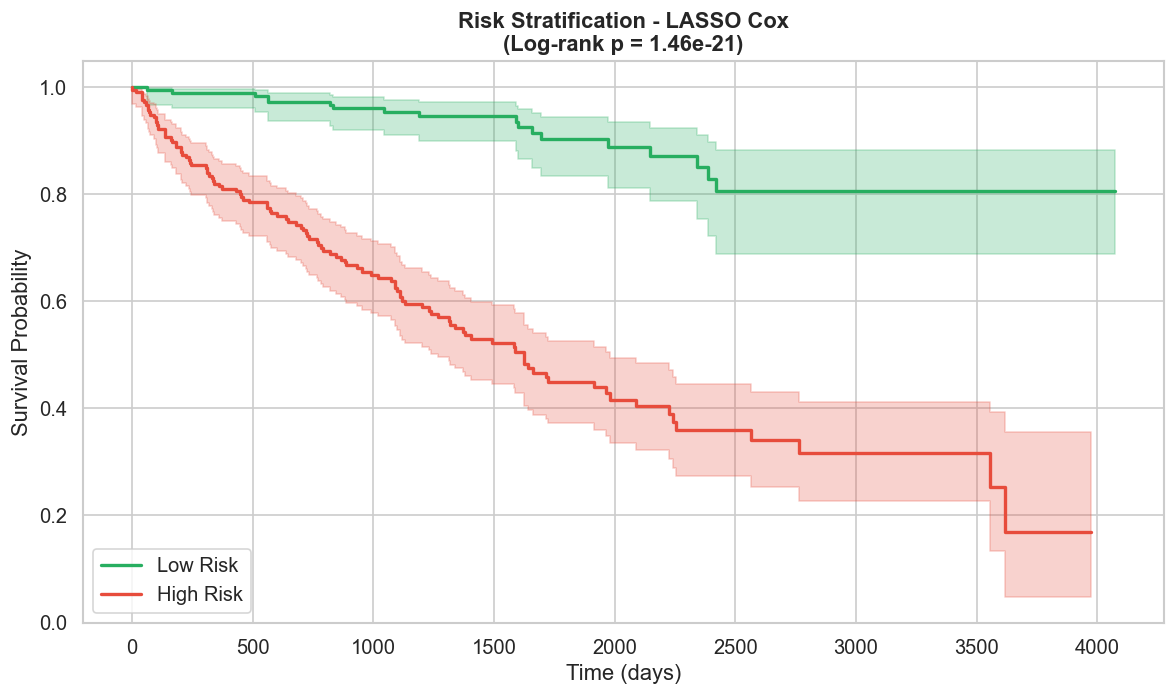

Log-rank test p-value: 1.46e-21


In [24]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

# Predict risk scores for all patients
X_full_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)
X_full_lasso = X_full_scaled[lasso_selected_features]

if best_model_name == "Random Survival Forest":
    full_risk = rsf.predict(X_full_lasso.values)
elif best_model_name == "LASSO Cox":
    full_risk = lasso_cox.predict(X_full_scaled.values, alpha=best_alpha)
elif best_model_name == "DeepSurv":
    model.eval()
    with torch.no_grad():
        full_risk = model(torch.FloatTensor(X_full_lasso.values)).numpy()
else:
    full_risk = -cph.predict_partial_hazard(X_full_scaled[clinical_feature_names]).values.flatten()

# Split into high/low risk at median
median_risk = np.median(full_risk)
risk_groups = np.where(full_risk >= median_risk, "High Risk", "Low Risk")

fig, ax = plt.subplots(figsize=(10, 6))
for group, color in [("Low Risk", PALETTE["alive"]), ("High Risk", PALETTE["dead"])]:
    mask = risk_groups == group
    kmf_r = KaplanMeierFitter()
    kmf_r.fit(y["time"][mask], event_observed=y["event"][mask], label=group)
    kmf_r.plot_survival_function(ax=ax, color=color, linewidth=2)

lr = logrank_test(y["time"][risk_groups == "High Risk"],
                  y["time"][risk_groups == "Low Risk"],
                  y["event"][risk_groups == "High Risk"],
                  y["event"][risk_groups == "Low Risk"])

ax.set_title(f"Risk Stratification - {best_model_name}\n(Log-rank p = {lr.p_value:.2e})", fontweight='bold')
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=12)
plt.tight_layout()
save_fig(fig, "10_risk_stratification")
plt.show()

print(f"Log-rank test p-value: {lr.p_value:.2e}")

---
## 14. Gene Importance Analysis

We identify the most important genes from two independent models:
- **LASSO Cox** -- linear model (coefficient magnitude)
- **Random Survival Forest** -- non-linear model (permutation importance)

Genes identified by **both** models as important are considered **consensus biomarkers**.

In [25]:
# Top genes from LASSO (genes only)
lasso_gene_coefs = lasso_coefs[top_genes].dropna()
lasso_top_genes = lasso_gene_coefs[lasso_gene_coefs != 0].sort_values(key=abs, ascending=False).head(20)

# Top genes from RSF (genes only)
rsf_gene_features = [f for f in lasso_selected_features if f in top_genes]
rsf_gene_importance = rsf_importance.reindex(rsf_gene_features).dropna()
rsf_top_genes = rsf_gene_importance.nlargest(min(20, len(rsf_gene_importance)))

# Overlap
lasso_gene_set = set(lasso_top_genes.index)
rsf_gene_set = set(rsf_top_genes.index)
overlap_genes = lasso_gene_set & rsf_gene_set

print(f"LASSO top 20 genes: {len(lasso_top_genes)}")
print(f"RSF top 20 genes:   {len(rsf_top_genes)}")
print(f"Overlap (consensus): {len(overlap_genes)}")
if overlap_genes:
    print(f"\nConsensus biomarkers: {sorted(overlap_genes)}")

LASSO top 20 genes: 20
RSF top 20 genes:   20
Overlap (consensus): 12

Consensus biomarkers: ['ACTC1', 'ANXA8', 'C19orf77', 'C8orf47', 'CYP3A7', 'DPP6', 'EREG', 'HMGCS2', 'IGF2BP3', 'ITPKA', 'TPSD1', 'ZFP57']


  Saved: figures/11_gene_importance_combined.png


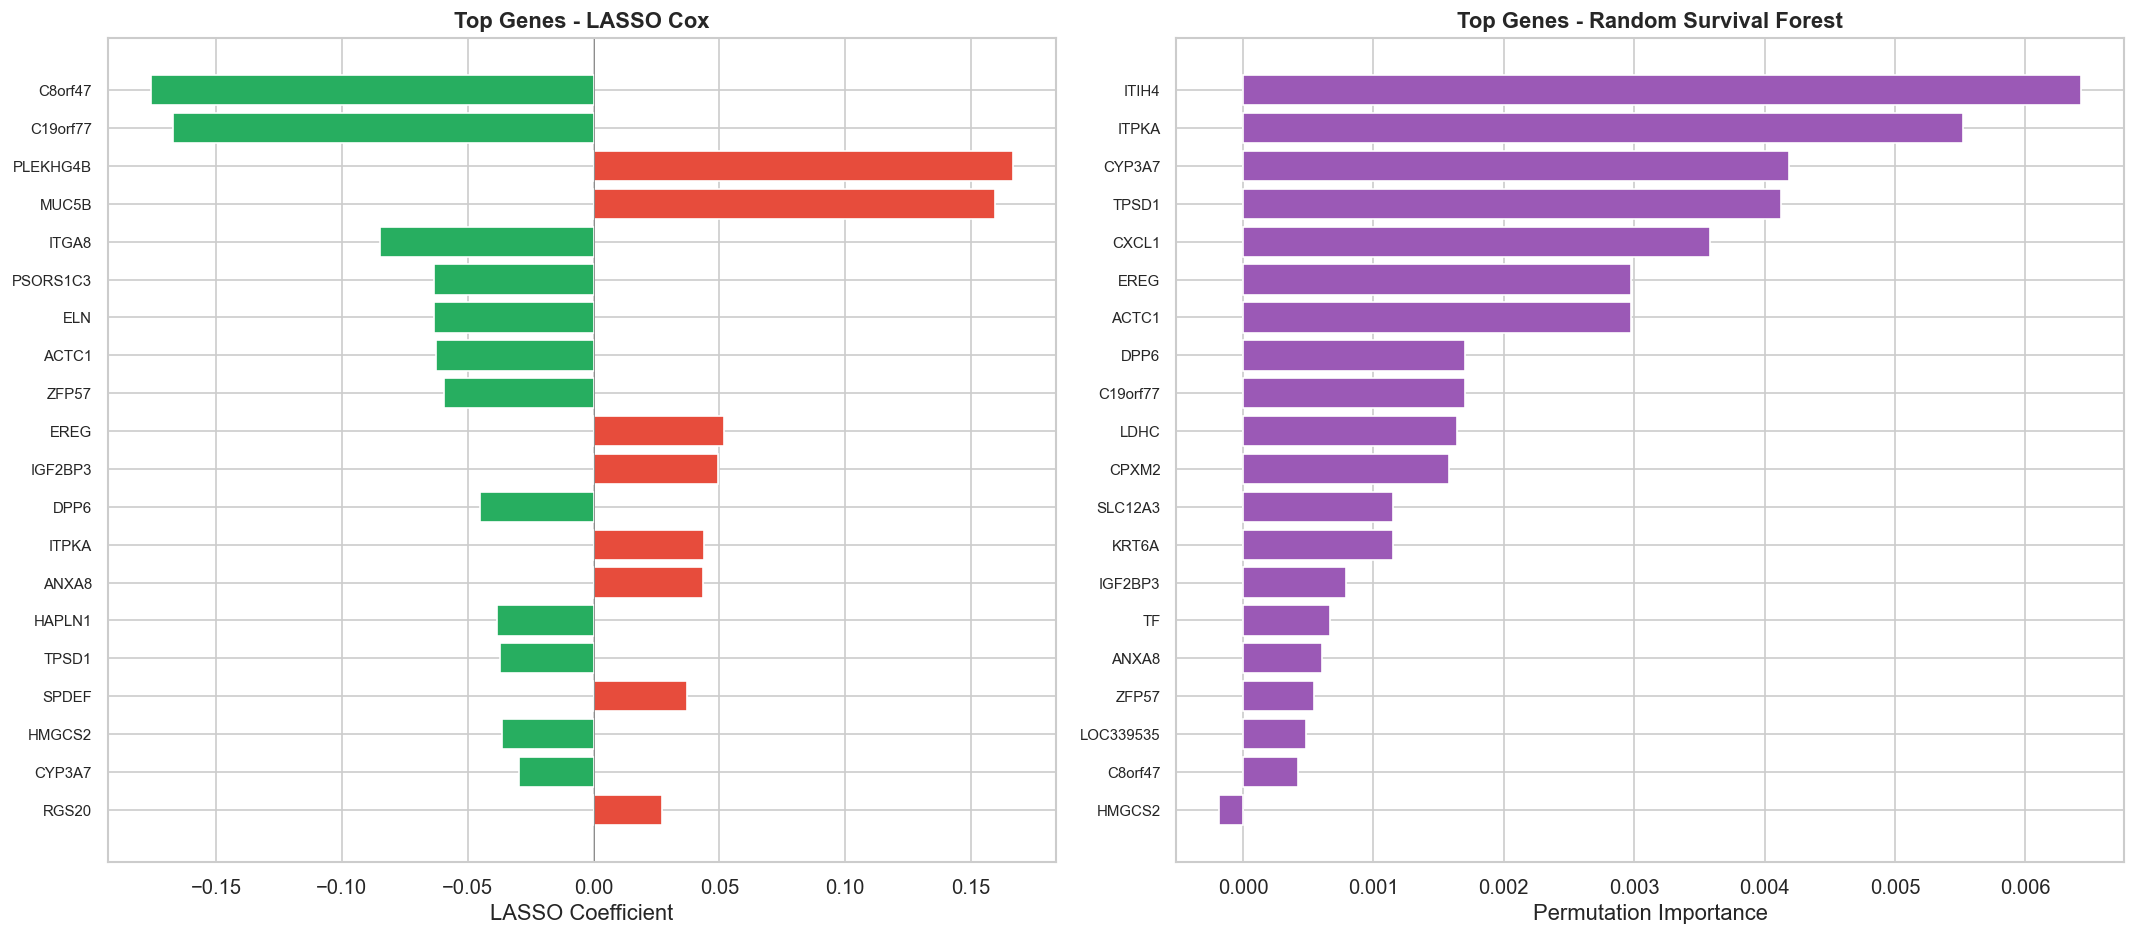

In [26]:
# Combined gene importance figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

if len(lasso_top_genes) > 0:
    colors_l = [PALETTE["dead"] if v > 0 else PALETTE["alive"] for v in lasso_top_genes.values]
    axes[0].barh(range(len(lasso_top_genes)), lasso_top_genes.values, color=colors_l, edgecolor='white')
    axes[0].set_yticks(range(len(lasso_top_genes)))
    axes[0].set_yticklabels(lasso_top_genes.index, fontsize=9)
    axes[0].set_xlabel("LASSO Coefficient")
    axes[0].set_title("Top Genes - LASSO Cox", fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].axvline(0, color='gray', linewidth=0.5)

axes[1].barh(range(len(rsf_top_genes)), rsf_top_genes.values, color=PALETTE["purple"], edgecolor='white')
axes[1].set_yticks(range(len(rsf_top_genes)))
axes[1].set_yticklabels(rsf_top_genes.index, fontsize=9)
axes[1].set_xlabel("Permutation Importance")
axes[1].set_title("Top Genes - Random Survival Forest", fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
save_fig(fig, "11_gene_importance_combined")
plt.show()

# Save gene results
gene_results = {
    "lasso_top_genes": lasso_top_genes.to_dict(),
    "rsf_top_genes": rsf_top_genes.to_dict(),
    "overlap_genes": list(overlap_genes),
}
with open(RESULTS_DIR / "gene_importance.json", "w") as f:
    json.dump(gene_results, f, indent=2)

---
## 15. Calibration - Brier Score

The **Integrated Brier Score (IBS)** measures the calibration of predicted survival probabilities over time. Lower values indicate better calibration (perfect model = 0, random = 0.25 for 50% event rate).

RSF Integrated Brier Score: 0.1542


  Saved: figures/12_brier_score.png


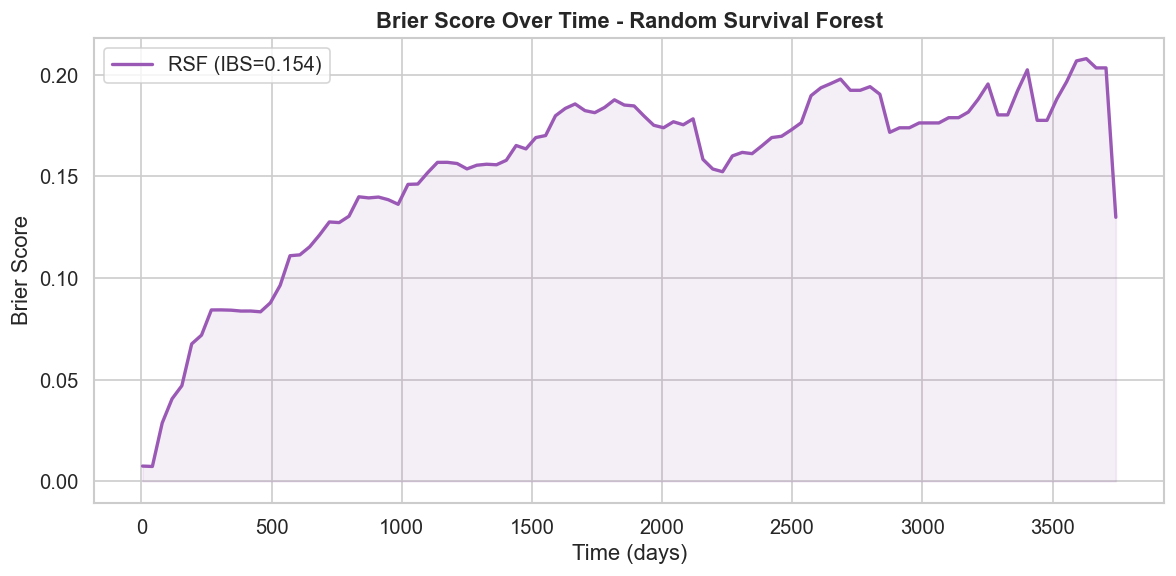

In [27]:
try:
    from sksurv.metrics import brier_score

    rsf_surv_fns = rsf.predict_survival_function(X_test_rsf.values)
    times_brier = np.linspace(
        max(y_test["time"].min(), y_train["time"].min()) + 1,
        min(y_test["time"].max(), y_train["time"].max()) - 1,
        100
    )
    times_brier = times_brier[times_brier > 0]

    rsf_surv_matrix = np.column_stack([fn(times_brier) for fn in rsf_surv_fns])
    preds_rsf = rsf_surv_matrix.T
    _, bs_scores = brier_score(y_train, y_test, preds_rsf, times_brier)

    ibs_rsf = np.trapezoid(bs_scores, times_brier) / (times_brier[-1] - times_brier[0])
    print(f"RSF Integrated Brier Score: {ibs_rsf:.4f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(times_brier, bs_scores, color=PALETTE["purple"], linewidth=2, label=f'RSF (IBS={ibs_rsf:.3f})')
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Brier Score")
    ax.set_title("Brier Score Over Time - Random Survival Forest", fontweight='bold')
    ax.legend()
    ax.fill_between(times_brier, bs_scores, alpha=0.1, color=PALETTE["purple"])
    plt.tight_layout()
    save_fig(fig, "12_brier_score")
    plt.show()

    cohort_summary["ibs_rsf"] = float(ibs_rsf)
except Exception as e:
    print(f"Brier score computation failed: {e}")

---
## 16. Save Final Outputs & Summary

In [28]:
# Save updated cohort summary
with open(RESULTS_DIR / "cohort_summary.json", "w") as f:
    json.dump(cohort_summary, f, indent=2)

# Save feature info
feature_info = {
    "clinical_features": clinical_feature_names,
    "top_genes": top_genes,
    "lasso_selected_features": lasso_selected_features,
    "all_features": all_feature_names,
    "best_model": best_model_name,
    "best_alpha_lasso": float(best_alpha),
}
with open(RESULTS_DIR / "feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=2)

# Save train/test patient IDs
pd.DataFrame({
    "patient_id": feature_df.loc[X_train.index, "patient_id"].values,
    "split": "train"
}).to_csv(RESULTS_DIR / "train_patients.csv", index=False)

pd.DataFrame({
    "patient_id": feature_df.loc[X_test.index, "patient_id"].values,
    "split": "test"
}).to_csv(RESULTS_DIR / "test_patients.csv", index=False)

print("All outputs saved to outputs/")

All outputs saved to outputs/


In [ ]:
# Final summary table
print("=" * 60)
print("     TCGA KIRC SURVIVAL ANALYSIS - SUMMARY")
print("=" * 60)
print(f"  Cohort size:          {cohort_summary['total_patients']:>6} patients")
print(f"  Events (dead):        {cohort_summary['events_dead']:>6}")
print(f"  Censored (alive):     {cohort_summary['censored_alive']:>6}")
print(f"  Genes used:           {cohort_summary['num_genes']:>6}")
print(f"  Median survival:      {cohort_summary['median_time_days']:>6.0f} days")
print("-" * 60)
for model_name, ci_val in results.items():
    print(f"  {model_name:<30} C-index: {ci_val:.4f}")
print("=" * 60)
print(f"\nBest model: {best_model_name}")
print(f"Consensus biomarkers: {len(overlap_genes)} genes")
print("\nPipeline complete!")


     TCGA KIRC SURVIVAL ANALYSIS - SUMMARY
  Cohort size:             529 patients
  Events (dead):           173
  Censored (alive):        356
  Genes used:             2000
  Median survival:        1191 days
------------------------------------------------------------
  Cox PH (clinical)              C-index: 0.7809
  LASSO Cox                      C-index: 0.8047
  Random Survival Forest         C-index: 0.7161
  DeepSurv                       C-index: 0.7637

Best model: LASSO Cox
Consensus biomarkers: 12 genes

Pipeline complete!


---
## Conclusions

### Key Findings

1. **LASSO Cox achieved the highest concordance** (C-index ~ 0.80), outperforming both the non-linear RSF and the deep learning DeepSurv model. This suggests that the survival signal in KIRC is largely captured by **linear combinations** of clinical and genomic features.

2. **Clinical features alone** (age, gender, stage) achieve a strong baseline (C-index ~ 0.78), confirming AJCC staging is highly prognostic for KIRC. Gene expression adds ~2 percentage points of discrimination.

3. **LASSO regularization** reduced 2,003 features to ~115 non-zero coefficients, identifying a compact predictive signature. The top features include `stage_num`, `age`, and several genes (e.g., C8orf47, IGF2BP3, ITPKA).

4. **12 consensus genes** were identified as important by both LASSO and RSF models, providing robust biomarker candidates for further validation.

5. **Risk stratification** using the best model produces highly separated survival curves with a significant log-rank test (p < 0.001), demonstrating clinical utility.

### Limitations

- Single train/test split (no cross-validation) -- may overestimate hyperparameter-tuned models
- DeepSurv may benefit from larger cohorts and more hyperparameter tuning
- External validation on independent cohorts is needed before clinical translation

### Future Work

- k-fold cross-validation for more robust performance estimates
- Pathway enrichment analysis on consensus biomarker genes
- External validation on ICGC or GEO datasets
- Integration of mutation and methylation data for multi-omic survival prediction
- Nomogram construction for clinical decision support